In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

# Load data
df = pd.read_csv("mean_target.csv", sep=",")

features = ['num_enhancers','g','r','ma','mr','AC','RC']

# Remove invalid rows (if needed)
# df = df[df['weighted_std'] != 0]

# Target
y = df['weighted_avg']
X = df[features]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=45)
gb_model.fit(X_train, y_train)

# Feature importance
importance = gb_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=False)

# print("\n=== Gradient Boosting Feature Importance ===")
# print(importance_df.to_string(index=False, float_format="%.3f"))

# Print only AC and RC feature importance
ac_rc_df = importance_df[importance_df["Feature"].isin(["AC", "RC"])]
# print("\n=== AC and RC Feature Importance ===")
print(ac_rc_df.to_string(index=False, float_format="%.3f"))

Feature  Importance
     AC       0.095
     RC       0.031


In [26]:
# Plot
# plt.figure(figsize=(8, 5))
# plt.bar(importance_df["Feature"], importance_df["Importance"])
# plt.xticks(rotation=45)
# plt.ylabel("Importance")
# plt.title("Gradient Boosting Feature Importance")
# plt.tight_layout()
# plt.show()

In [25]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# from sklearn.linear_model import LinearRegression

# # Load data
# df = pd.read_csv("KM_noise .csv", sep=",")

# features = ['num_enhancers','g','r','ma','mr','AC','RC']

# # Target
# y = df['noise']
# X = df[features]

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # Standardize features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)

# # Polynomial features (degree 2)
# poly = PolynomialFeatures(degree=2, include_bias=False)
# X_train_poly = poly.fit_transform(X_train_scaled)

# # Train polynomial regression
# model = LinearRegression()
# model.fit(X_train_poly, y_train)

# # Get polynomial feature names (old + new sklearn)
# try:
#     poly_feature_names = poly.get_feature_names_out(features)
# except AttributeError:
#     poly_feature_names = poly.get_feature_names(features)

# # Absolute coefficient importance for each polynomial term
# coef_importance = np.abs(model.coef_)

# # ---- Aggregate to original parameters (single importance per parameter) ----
# param_importance = {f: 0.0 for f in features}

# for term, imp in zip(poly_feature_names, coef_importance):
#     for f in features:
#         if f in term:   # term contains that parameter (linear, squared, interaction)
#             param_importance[f] += imp

# importance_df = pd.DataFrame({
#     "Feature": list(param_importance.keys()),
#     "Importance": list(param_importance.values())
# }).sort_values("Importance", ascending=False)

# #print("\n=== Polynomial Regression (Degree 2) Single-Parameter Importance ===")
# print("\n=== Polynomial Regression (Degree 2) Single-Parameter Importance ===")
# print(importance_df.to_string(index=False, float_format="%.2f"))


# # Plot
# # plt.figure(figsize=(8, 5))
# # plt.bar(importance_df["Feature"], importance_df["Importance"])
# # plt.xticks(rotation=45)
# # plt.ylabel("Aggregated Importance (sum of |coefficients|)")
# # plt.title("Polynomial Regression (Degree 2) Parameter Importance")
# # plt.tight_layout()
# # plt.show()

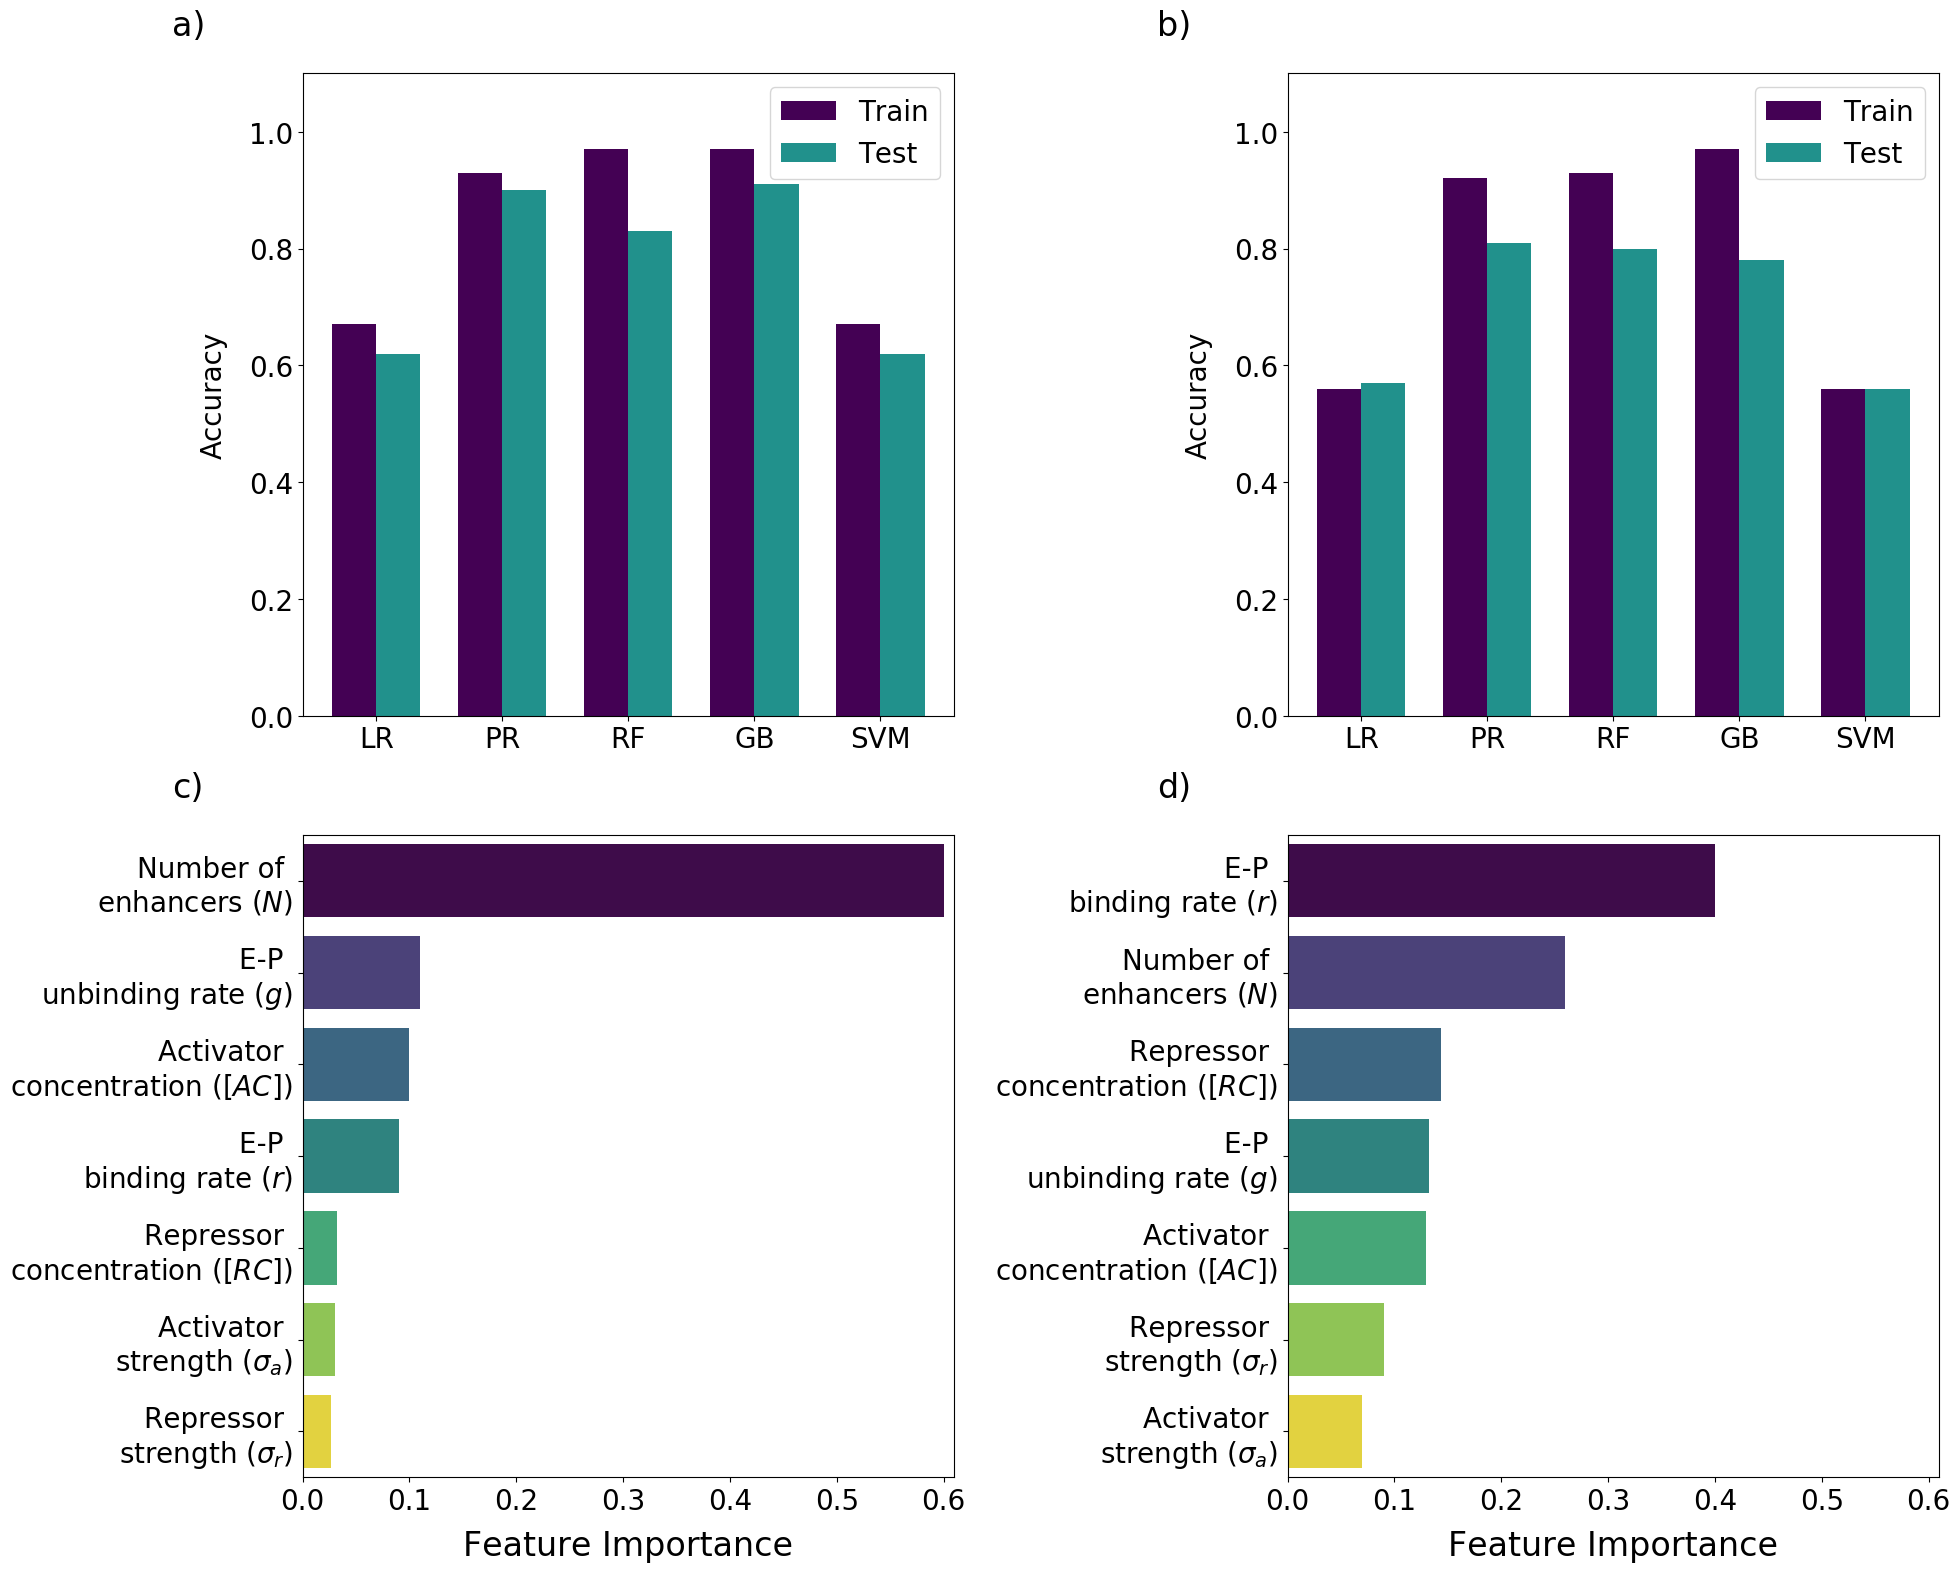

In [9]:
#figure
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use Arial font and set general font settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 20

# Define model names and x-axis positions
models = ["LR", "PR", "RF", "GB","SVM"]
x = np.arange(len(models))
bar_width = 0.35

# Accuracy data
mean_train = [0.67, 0.93, 0.97,0.97, 0.67]
mean_test = [0.62, 0.90, 0.83,0.91, 0.62]
noise_train = [0.56,0.92,0.93,0.97,0.56]
noise_test = [0.57,0.81,0.80,0.78,0.56]
# peak_train = [0.88, 0.72, 0.97, 0.67]
# peak_test = [0.83, 0.7, 0.93, 0.62]

# Feature importance data
mean_params = ['Number of \nenhancers ($N$)', "E-P \nunbinding rate ($g$)", "Activator \nconcentration ($[AC]$)","E-P \nbinding rate ($r$)", "Repressor \nconcentration ($[RC]$)","Activator \nstrength ($\sigma_a$)","Repressor \nstrength ($\sigma_r$)"]
mean_values = [0.6,0.11,0.1,0.09,0.032,0.03,0.027]

noise_params = ["E-P \nbinding rate ($r$)","Number of \nenhancers ($N$)", "Repressor \nconcentration ($[RC]$)", "E-P \nunbinding rate ($g$)","Activator \nconcentration ($[AC]$)","Repressor \nstrength ($\sigma_r$)","Activator \nstrength ($\sigma_a$)"]
noise_values = [0.4, 0.26, 0.144, 0.132,0.13,0.09,0.07]

# robustness_params = ["Chromatin \n Accessibility",'Multiple \n enhancers', "TF \n Strength", "TF \n Concentration"]
# robustness_values = [1.0, 0.68, 0.45, 0.38]

# Colors
accuracy_colors = plt.cm.viridis(np.linspace(0,1,3))#['#000080ff', '#d40000ff']
importance_colors = plt.cm.viridis(np.linspace(0,1,7))#['#00008ff', '', 'cyan', 'gray','gray','gray','','']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
plt.subplots_adjust(wspace=0.25, hspace=0.4)
letters = ['a', 'b', 'c', 'd', 'e', 'f']

# First row: Accuracy plots
accuracy_data = [
    (mean_train, mean_test),
    (noise_train, noise_test)
]

for i, (train, test) in enumerate(accuracy_data):
    ax = axes[0, i]
    ax.bar(x - bar_width/2, train, width=bar_width, label='Train', color=accuracy_colors[0])
    ax.bar(x + bar_width/2, test, width=bar_width, label='Test', color=accuracy_colors[1])
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Accuracy",fontsize=20, labelpad=15)
    ax.legend()
    ax.grid(False)
    ax.text(-0.2, 1.1, f"{letters[i]})", transform=ax.transAxes,
            fontsize=24, va='top', ha='left')

# Second row: Feature importance plots
importance_data = [
    (mean_params, mean_values),
    (noise_params, noise_values)
]

for i, (features, values) in enumerate(importance_data):
    ax = axes[1, i]
    sns.barplot(x=values, y=features, ax=ax, palette=importance_colors)
    ax.set_xlim(0, 0.61)
    ax.set_xlabel("Feature Importance", fontsize=24,labelpad=10)
    ax.grid(False)
    ax.text(-0.2, 1.1, f"{letters[i+2]})", transform=ax.transAxes,
            fontsize=24, va='top', ha='left')

# Save and show
plt.tight_layout()
plt.savefig('Figure_2.png', dpi=300)
plt.show()
